Hola **Luis**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
--
</div>

# SPRINT 9 PROYECTO

ANALITICA DE SHOWZ
- Objetivo: Ayudar a optimizar los gatos de marketing

## Paso 1 Acceda los datos y preparalos para el analisis


In [1]:
#Comenzamos importando las librerias
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st
import seaborn as sns

In [2]:
#Cargamos los datasets en las variables

orders_log = pd.read_csv('https://raw.githubusercontent.com/LuisPeza/Proyecto_9/refs/heads/main/orders_log_us.csv')
visits_log = pd.read_csv('https://raw.githubusercontent.com/LuisPeza/Proyecto_9/refs/heads/main/visits_log_us.csv')
costs_us = pd.read_csv('https://raw.githubusercontent.com/LuisPeza/Proyecto_9/refs/heads/main/costs_us.csv')

In [3]:
#Vamos a darle un vistazo a los datos con info

orders_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [4]:
visits_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB


In [5]:
costs_us.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB


In [6]:
print(orders_log.sample(5))
print(visits_log.sample(5))
print(costs_us.sample(5))

                    Buy Ts  Revenue                   Uid
15970  2017-11-03 15:20:00     2.20   7103173002200051683
26616  2017-12-28 10:52:00     3.05  12885695339256095107
17001  2017-11-11 09:51:00     1.83  10373876622191378148
41506  2018-03-24 12:26:00     0.49  17524370468859157580
23467  2017-12-11 22:31:00     1.83  12071438026309710694
         Device               End Ts  Source Id             Start Ts  \
331113  desktop  2017-12-03 22:02:00          1  2017-12-03 20:38:00   
184119  desktop  2017-12-21 17:09:00          4  2017-12-21 16:25:00   
333015  desktop  2018-01-16 13:57:00          3  2018-01-16 13:56:00   
99290   desktop  2017-12-08 18:01:00          2  2017-12-08 17:24:00   
163820  desktop  2017-12-11 21:17:00          4  2017-12-11 20:48:00   

                         Uid  
331113  10553815444202384166  
184119  15709491712662659898  
333015   2044819675755814900  
99290    5934415971014636742  
163820   4604257880492705775  
      source_id          dt  cost

- Con la vista de los DF vemos que tenemos minusculas, mayusculas y espacios en blanco en los nombres de las columnas, vamos a realizar snakecase, tambien vemos que tenemos tipos de datos erroneos vamos a corregirlos tambien. 

In [7]:
#Hacemos snakes en los nombres de las columnas
orders_log.columns = orders_log.columns.str.replace(' ','_').str.lower()

In [8]:
orders_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   buy_ts   50415 non-null  object 
 1   revenue  50415 non-null  float64
 2   uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB


In [9]:
#Hacemos snakes en los nombres de las columnas
visits_log.columns = visits_log.columns.str.replace(' ','_').str.lower()

In [10]:
visits_log.head(5)

,device,end_ts,source_id,start_ts,uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [11]:
#Hacemos snakes en los nombres de las columnas
costs_us.columns = costs_us.columns.str.replace(' ','_').str.lower()

In [12]:
costs_us.head()

,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [13]:
# Vamos a corregir los tipos de datos del DF de costos
costs_us['dt'] = pd.to_datetime(costs_us['dt'])

In [14]:
costs_us.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB


In [15]:
# Vamos a corregir los tipos de datos del DF orders
orders_log['buy_ts'] = pd.to_datetime(orders_log['buy_ts'])

In [16]:
orders_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   buy_ts   50415 non-null  datetime64[ns]
 1   revenue  50415 non-null  float64       
 2   uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB


In [17]:
# Vamos a corregir los tipos de datos del DF orders
visits_log['start_ts'] = pd.to_datetime(visits_log['start_ts'])
visits_log['end_ts'] = pd.to_datetime(visits_log['end_ts'])


In [18]:
visits_log.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   device     359400 non-null  object        
 1   end_ts     359400 non-null  datetime64[ns]
 2   source_id  359400 non-null  int64         
 3   start_ts   359400 non-null  datetime64[ns]
 4   uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB


## Paso 2. Haz informes y calcula métricas

### 1. Visitas:

#### 1.1. ¿Cuántas personas lo usan cada día, semana y mes? 

In [19]:
#vamos a obtener las columnas de day,week y month de la columna start_ts de la tabla de visits_log
visits_log['day'] = visits_log['end_ts'].dt.day
visits_log['week'] = visits_log['end_ts'].dt.isocalendar().week
visits_log['month'] = visits_log['end_ts'].dt.month
visits_log['year'] = visits_log['end_ts'].dt.year



In [20]:
visits_log.head()

,device,end_ts,source_id,start_ts,uid,day,week,month,year
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,20,51,12,2017
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,19,8,2,2018
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,1,26,7,2017
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,20,20,5,2018
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,27,52,12,2017


In [21]:
#Hacemos una agrupacion por dia, semana y mes y contamos el identificador del usuario
personas_por_dia = visits_log.groupby('day').agg({'uid':'count'})

In [22]:
print("Las personas que lo usan por dia son:\t",personas_por_dia)

Las personas que lo usan por dia son:	        uid
day       
1    10491
2    11011
3    11185
4    11338
5    11879
6    12103
7    12038
8    11505
9    11166
10   11251
11   11228
12   11621
13   11983
14   11804
15   11805
16   11729
17   11430
18   11262
19   11865
20   12062
21   11767
22   11995
23   11517
24   13999
25   13261
26   13005
27   12696
28   12386
29   11000
30   10031
31    6987


In [23]:
#Hacemos una agrupacion por dia, semana y mes y contamos el identificador del usuario
personas_por_semana = visits_log.groupby('week').agg({'uid':'count'})

In [24]:
print("Las personas que lo usan por semana son:\t",personas_por_semana)

Las personas que lo usan por semana son:	         uid
week       
1      8043
2      7879
3      8311
4      8490
5      9796
6      9406
7      9278
8      8922
9      8780
10     8144
11     7492
12     9382
13     5878
14     6238
15     6382
16     6766
17     6573
18     4503
19     4797
20     6094
21     5936
22     8162
23     4938
24     3213
25     3271
26     3512
27     3824
28     5106
29     4575
30     3070
31     2731
32     2783
33     3127
34     3586
35     4293
36     5114
37     5012
38     5714
39     7310
40     8881
41     8319
42     8334
43     8711
44     8639
45     8293
46     9657
47    13565
48    10408
49    10304
50    10118
51     8502
52     9238


In [25]:
#Hacemos una agrupacion por dia, semana y mes y contamos el identificador del usuario
personas_por_mes = visits_log.groupby('month').agg({'uid':'count'})

In [26]:
print("Las personas que lo usan por mes son:\t",personas_por_mes)

Las personas que lo usan por mes son:	          uid
month       
1      36926
2      37192
3      35683
4      26510
5      26628
6      16513
7      17828
8      14355
9      23900
10     37905
11     43970
12     41990


#### 1.2. ¿Cuántas sesiones hay por día? (Un usuario puede tener más de una sesión).

In [27]:
#Hacemos una agrupacion por dia y contamos los valores unicos de las sesion de los ususarios
sesiones_por_dia = visits_log.groupby('day').agg({'uid':'nunique'})

In [28]:
unicos = visits_log['uid'].nunique()

In [29]:
print(unicos)

228169


In [30]:
print(sesiones_por_dia)

       uid
day       
1     9242
2     9822
3    10048
4    10178
5    10516
6    10665
7    10715
8    10303
9     9951
10    9999
11    9985
12   10246
13   10519
14   10384
15   10461
16   10297
17   10078
18    9938
19   10405
20   10681
21   10418
22   10668
23   10201
24   11972
25   11644
26   11404
27   11127
28   10773
29    9705
30    8952
31    6227


#### 3.- ¿Cuál es la duración de cada sesión?

In [31]:
resta_visitas = visits_log['end_ts'] - visits_log['start_ts']

In [32]:
#Extraer los minutos de la diferencia de tiempo
visits_log['minutos_sesion'] = resta_visitas.dt.total_seconds() / 60

In [33]:
visits_log.head()

,device,end_ts,source_id,start_ts,uid,day,week,month,year,minutos_sesion
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062,20,51,12,2017,18.0
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740,19,8,2,2018,28.0
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527,1,26,7,2017,0.0
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214,20,20,5,2018,24.0
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168,27,52,12,2017,0.0


#### 4.- ¿Con qué frecuencia los usuarios regresan?

In [34]:
#AGrupamos por usuario en busca de la primera fecha
first_activity_date = visits_log.groupby('uid')['start_ts'].min()
first_activity_date.name = 'first_activity_date'


In [35]:
print(first_activity_date)

uid
11863502262781         2018-03-01 17:27:00
49537067089222         2018-02-06 15:55:00
297729379853735        2017-06-07 18:47:00
313578113262317        2017-09-18 22:49:00
325320750514679        2017-09-30 14:29:00
                               ...        
18446403737806311543   2017-11-30 03:36:00
18446424184725333426   2017-12-06 20:32:00
18446556406699109058   2018-01-01 16:29:00
18446621818809592527   2017-12-27 13:27:00
18446676030785672386   2017-10-04 16:01:00
Name: first_activity_date, Length: 228169, dtype: datetime64[ns]


In [36]:
#Agramos la nueva columna primera_actividad_fecha al dataset visits_log
actividad_usuario = visits_log.join(first_activity_date, on= 'uid')

In [37]:
actividad_usuario['activity_week'] = pd.to_datetime(
    actividad_usuario['start_ts'], unit='d'
) - pd.to_timedelta( actividad_usuario['start_ts'].dt.dayofweek, unit='d')

actividad_usuario['first_activity_week'] = pd.to_datetime(actividad_usuario['first_activity_date'], unit='d' )
-pd.to_timedelta(actividad_usuario['first_activity_date'].dt.dayofweek,unit='d') 

# Cálculo del ciclo de vida de la cohorte en semanas
actividad_usuario['cohort_lifetime'] = (actividad_usuario['activity_week'] -actividad_usuario['first_activity_week']) / np.timedelta64(1, 'W')
actividad_usuario['cohort_lifetime'] = actividad_usuario['cohort_lifetime'].astype(int)

In [38]:
# Construimos el dataframe con cohortes
cohorts = (actividad_usuario.groupby(['first_activity_week','cohort_lifetime']).agg({'uid':'nunique'}).reset_index())
#Contrustuimos el DF
initial_users_count = cohorts[cohorts['cohort_lifetime']==0][['first_activity_week','uid']]
# Renombra la columna del DataFrame
initial_users_count = initial_users_count.rename(columns={'uid':'cohort_users'}) 
# Une las cohortes del DataFrame e initital_users_count
cohorts = cohorts.merge(initial_users_count, on='first_activity_week')
# Calcula la tasa de retención
cohorts['retention'] = cohorts['uid']/cohorts['cohort_users'] 
cohorts['first_activity_week'] = cohorts['first_activity_week'].dt.date 

In [39]:
retention_pivot =  cohorts.pivot_table(index='first_activity_week',
                                      columns='cohort_lifetime',
                                       values= 'retention',
                                       aggfunc='sum')# Compila la tabla dinámica
# Imprime la tabla dinámica
print(retention_pivot)

cohort_lifetime         0          1          2          3          4   \
first_activity_week                                                      
2017-06-01           463.0  33.500000  26.333333  29.500000  23.250000   
2017-06-02           445.0  17.333333  11.833333  15.333333  19.833333   
2017-06-03           339.0  12.833333  10.833333  12.250000  11.333333   
2017-06-04           367.0  15.000000   9.833333  13.333333  11.833333   
2017-06-05           532.0  18.833333  19.916667  19.833333  16.750000   
...                    ...        ...        ...        ...        ...   
2018-05-27           324.0        NaN        NaN        NaN        NaN   
2018-05-28           471.0        NaN        NaN        NaN        NaN   
2018-05-29           441.0        NaN        NaN        NaN        NaN   
2018-05-30           590.0        NaN        NaN        NaN        NaN   
2018-05-31           764.0        NaN        NaN        NaN        NaN   

cohort_lifetime             5        

### 2. Ventas:

#### 1.- ¿Cuándo empieza la gente a comprar?

- (En el análisis de KPI, generalmente nos interesa saber el tiempo que transcurre entre el registro y la conversión, es decir, cuando el usuario se convierte en cliente. Por ejemplo, si el registro y la primera compra ocurren el mismo día, el usuario podría caer en la categoría Conversion 0d. Si la primera compra ocurre al día siguiente, será Conversion 1d. Puedes usar cualquier enfoque que te permita comparar las conversiones de diferentes cohortes para que puedas determinar qué cohorte o canal de marketing es más efectivo.)

In [40]:
#Vamos a unir la columna visits_log con orders_log
#Con esta agrupación tenemos solo las filas de los usuarios que tienen una compra y descartamos las sesiones que no lo tienen.
visits_orders = orders_log.merge(visits_log, on='uid',how='inner')

In [41]:
visits_orders.head(5)

,buy_ts,revenue,uid,device,end_ts,source_id,start_ts,day,week,month,year,minutos_sesion
0,2017-06-01 00:10:00,17.00,10329302124590727494,desktop,2017-06-01 00:11:00,1,2017-06-01 00:09:00,1,22,6,2017,2.0
1,2017-06-01 00:25:00,0.55,11627257723692907447,desktop,2017-06-01 00:25:00,2,2017-06-01 00:14:00,1,22,6,2017,11.0
2,2017-06-01 00:27:00,0.37,17903680561304213844,desktop,2017-06-01 00:34:00,2,2017-06-01 00:25:00,1,22,6,2017,9.0
3,2017-06-01 00:29:00,0.55,16109239769442553005,desktop,2017-06-01 00:33:00,2,2017-06-01 00:14:00,1,22,6,2017,19.0
4,2017-06-01 07:58:00,0.37,14200605875248379450,desktop,2017-06-01 07:59:00,3,2017-06-01 07:31:00,1,22,6,2017,28.0


In [42]:
#Hacemos un groupby para saber cuantos usuarios realizaron un pedido
contar_usuarios_pedidos = (visits_orders.groupby('uid')['buy_ts'].nunique())
contar_usuarios_pedidos.columns = 'buy_per_user'

In [43]:
print(contar_usuarios_pedidos)

uid
313578113262317         1
1575281904278712        2
2429014661409475        1
2464366381792757        1
2551852515556206        2
                       ..
18445147675727495770    1
18445407535914413204    3
18445601152732270159    1
18446156210226471712    1
18446167067214817906    1
Name: buy_ts, Length: 36523, dtype: int64


In [44]:
#Hacemos una descripcion para ver los valores minimos y maximos de pedidos por un usuario y ver el promedio de pedidos
contar_usuarios_pedidos.describe()

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: buy_ts, dtype: float64

- Vemos que un usuario si llega a tener mas de una compra

In [45]:
#Obtenemos la primera sesion y ultima de cada usuario y los guardad
primer_fecha = visits_orders.groupby('uid').agg(primera_sesion = ('start_ts','min'),
                                               ultima_sesion = ('end_ts','max')).reset_index()
unir = visits_orders.merge(primer_fecha, on='uid', how='inner')


In [46]:
unir.sample(5)

,buy_ts,revenue,uid,device,end_ts,source_id,start_ts,day,week,month,year,minutos_sesion,primera_sesion,ultima_sesion
225849,2017-09-27 08:41:00,2.44,3263486045884611639,desktop,2017-10-17 13:08:00,1,2017-10-17 11:52:00,17,42,10,2017,76.0,2017-06-01 08:51:00,2018-05-31 17:25:00
89865,2017-06-14 13:01:00,1.22,11920452646463905188,desktop,2018-03-21 13:25:00,4,2018-03-21 13:21:00,21,12,3,2018,4.0,2017-06-01 11:38:00,2018-05-30 09:40:00
492351,2017-12-27 16:21:00,24.44,5539673724080479777,desktop,2017-12-16 22:51:00,3,2017-12-16 22:09:00,16,50,12,2017,42.0,2017-09-07 13:45:00,2018-04-17 15:58:00
626635,2018-05-24 22:04:00,0.73,17971568743625265929,desktop,2018-05-24 22:06:00,5,2018-05-24 22:00:00,24,21,5,2018,6.0,2017-12-16 11:56:00,2018-05-24 22:06:00
755865,2018-05-23 19:04:00,4.89,268208395083179259,desktop,2018-05-28 11:56:00,5,2018-05-28 11:55:00,28,22,5,2018,1.0,2018-04-25 13:14:00,2018-05-31 20:46:00


In [47]:
unir['dias_hasta_compra'] = (unir['buy_ts'] - unir['primera_sesion']).dt.days

In [48]:
columnas_ = ['uid','buy_ts','start_ts','end_ts','primera_sesion','ultima_sesion','minutos_sesion','month','year','dias_hasta_compra']

unir_nuevo = unir[columnas_]


In [49]:
unir_nuevo.sample(5)

,uid,buy_ts,start_ts,end_ts,primera_sesion,ultima_sesion,minutos_sesion,month,year,dias_hasta_compra
245489,3263486045884611639,2017-12-12 18:32:00,2017-09-05 08:44:00,2017-09-05 08:59:00,2017-06-01 08:51:00,2018-05-31 17:25:00,15.0,9,2017,194
33815,3644482766749211722,2017-12-04 15:11:00,2017-07-13 13:19:00,2017-07-13 13:40:00,2017-06-01 09:22:00,2018-05-11 17:57:00,21.0,7,2017,186
548640,16442599152140519378,2017-11-08 14:02:00,2017-11-07 11:21:00,2017-11-07 11:39:00,2017-09-22 08:32:00,2017-12-31 09:16:00,18.0,11,2017,47
406169,10534330097262531592,2017-11-19 13:07:00,2018-04-16 11:27:00,2018-04-16 11:37:00,2017-06-01 22:55:00,2018-05-31 11:27:00,10.0,4,2018,170
214984,3263486045884611639,2017-07-15 14:46:00,2017-10-04 11:31:00,2017-10-04 11:31:00,2017-06-01 08:51:00,2018-05-31 17:25:00,0.0,10,2017,44


In [50]:
unir_nuevo['dias_hasta_compra'].describe()

count    761807.000000
mean        130.273857
std          99.354584
min           0.000000
25%          40.000000
50%         117.000000
75%         207.000000
max         364.000000
Name: dias_hasta_compra, dtype: float64

In [51]:
#Damos un slice para solo seleccionar datos del 2018
unir_nuevo_2018 = unir_nuevo[unir_nuevo['year']==2018]
#Hacemos una agruparacion de los meses para ver en que mes compra la gente desde su primera sesion
year_2018 = unir_nuevo_2018.groupby('month')['dias_hasta_compra'].mean().round(2)


In [52]:
print(year_2018)

month
1    127.55
2    118.95
3    126.01
4    120.12
5    111.23
6      0.20
Name: dias_hasta_compra, dtype: float64


In [53]:
print("El promedio de dias que pasan hasta la primer compra en el año del 2018 es de:", year_2018.mean().round(2))

El promedio de dias que pasan hasta la primer compra en el año del 2018 es de: 100.68


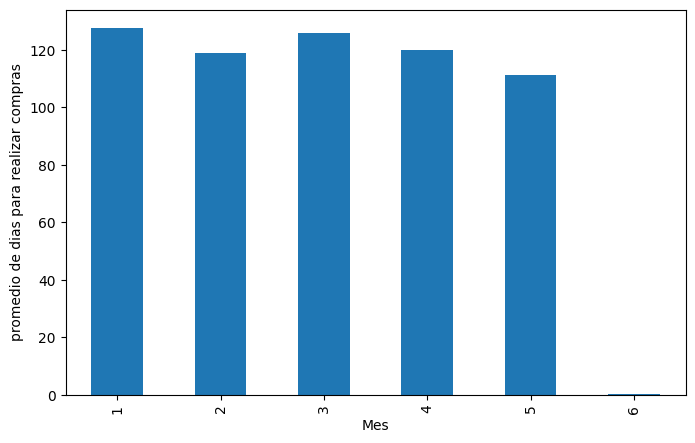

In [54]:
#Hacemos un grafico de barras
year_2018.plot(kind ='bar', figsize=(8,5))
plt.xlabel('Mes')
plt.ylabel('promedio de dias para realizar compras')
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Excelente! Realizaste los cálculos adecuados para mostrar gráficas claras que se acompañan muy bien con tus interpretaciones dejando así un proceso de análisis súper claro
</div>

In [55]:
#Damos un slice para solo seleccionar datos del 2017
unir_nuevo_2017 = unir_nuevo[unir_nuevo['year']==2017]
#Hacemos una agruparacion de los meses para ver en que mes compra la gente desde su primera sesion
year_2017 = unir_nuevo_2017.groupby('month')['dias_hasta_compra'].mean().round(2)

In [56]:
year_2017

month
6     154.58
7     140.15
8     141.96
9     145.00
10    139.85
11    134.05
12    132.89
Name: dias_hasta_compra, dtype: float64

In [57]:
print("El promedio de dias que pasan hasta la primer compra en el año del 2017 es de:", year_2017.mean().round(2))

El promedio de dias que pasan hasta la primer compra en el año del 2017 es de: 141.21


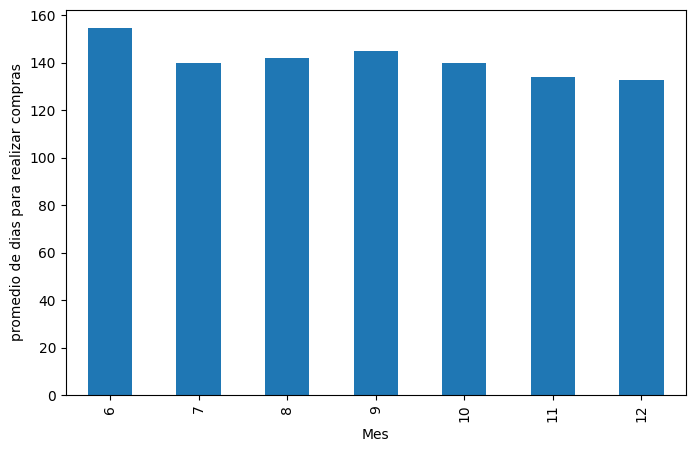

In [58]:
#Hacemos un grafico de barras
year_2017.plot(kind ='bar', figsize=(8,5))
plt.xlabel('Mes')
plt.ylabel('promedio de dias para realizar compras')
plt.show()

In [59]:

#Hacemos una agruparacion de los meses para ver en que mes compra la gente desde su primera sesion
por_2017 = unir_nuevo_2017.groupby('year')['dias_hasta_compra'].mean().round(2)
print(por_2017)

year
2017    138.93
Name: dias_hasta_compra, dtype: float64


In [60]:
#Hacemos una agruparacion de los meses para ver en que mes compra la gente desde su primera sesion
por_2018 = unir_nuevo_2018.groupby('year')['dias_hasta_compra'].mean().round(2)
print(por_2018)

year
2018    120.95
Name: dias_hasta_compra, dtype: float64


#### 2.- ¿Cuántos pedidos hacen durante un periodo de tiempo dado.?

In [61]:
#Vamos a ver con el cohorte de mes cuantos pedidos hacen
#cohorte_mes = 
cohorte_mes = unir.groupby(['year','month'])['buy_ts'].count()

In [62]:
cohorte_mes

year  month
2017  6         25983
      7         28991
      8         32560
      9         60736
      10        71497
      11        72414
      12       102929
2018  1         77642
      2         82794
      3         75990
      4         60154
      5         70112
      6             5
Name: buy_ts, dtype: int64

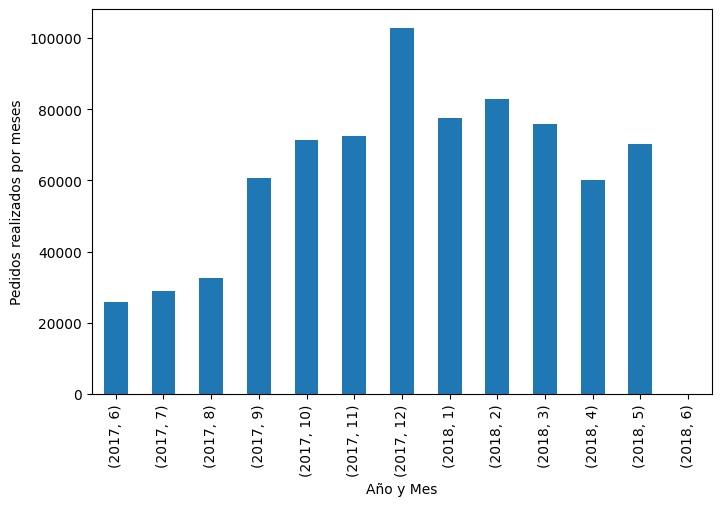

In [63]:
#Haremos un grafico para ver mejor los datos
#Hacemos un grafico de barras
cohorte_mes.plot(kind ='bar', figsize=(8,5))
plt.xlabel('Año y Mes')
plt.ylabel('Pedidos realizados por meses')
plt.show()

- Vemos que el mes con mas ventas en Diciembre del 2017 con arriba de 100,000 pedidos y los meses con menos ventas estan en Junio del 2017 y Junio del 2018. Se tendra alguna feriado o fecha importante sobre esos meses que los pedidos no fueron muchos. 

In [64]:
#Ahora vemos en que año se realizaron mas pedidos 
cohorte_año = unir.groupby('year')['buy_ts'].count()

In [65]:
cohorte_año

year
2017    395110
2018    366697
Name: buy_ts, dtype: int64

- Vemos que el año 2017 hubo mas pedidos que el año 2018

#### 3.- ¿Cuál es el tamaño promedio de compra.?

In [66]:
#Obtenemos el ingreso total
ingresos_totales = unir['revenue'].sum()
#obtenemos el numero de transacciones 
numero_compras = unir['buy_ts'].count()

In [67]:
ingresos_totales

6962207.35

In [68]:
numero_compras

761807

In [69]:
promedio_compras = ingresos_totales/numero_compras

In [70]:
print("El promedio de compras fue de:",promedio_compras.round(2))

El promedio de compras fue de: 9.14


In [71]:
#Podemos obtener el promedio de compras por meses
promedio_compras_mes = unir.groupby(['year','month']).agg(ingresos_totales=('revenue','sum'))                                            

In [72]:
promedio_compras_mes

ingresos_totales
year month                  
2017 6             253263.14
     7             223992.39
     8             228454.71
     9             689620.82
     10            597245.28
     11            733445.02
     12           1092071.86
2018 1             608879.83
     2             726913.15
     3             681632.40
     4             549621.03
     5             577045.36
     6                 22.36

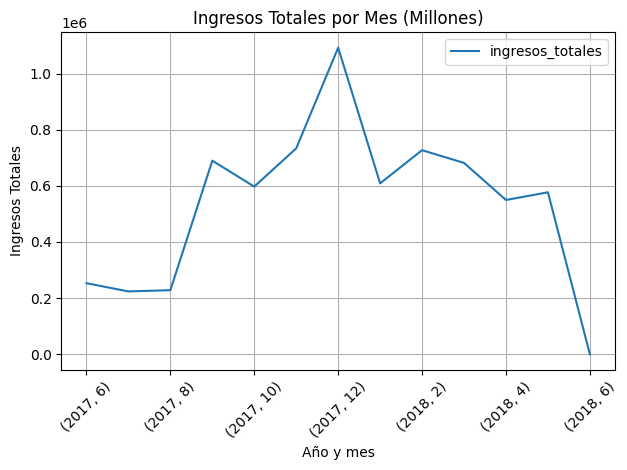

In [73]:
#Creamos un grafico para ver la tendencia del promedio de compras a travez del tiempo
promedio_compras_mes.plot()
plt.title('Ingresos Totales por Mes (Millones)')
plt.xlabel('Año y mes')
plt.ylabel('Ingresos Totales')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Notamos que tenemos un pico significativo en el año 2017 en el mes de diciembre, este sera por las fechas de navidad que es cuando mas estan activos los usuarios en comprar. En el mes de junio del 2018 las ventas fueron las menores en todo este dataset

#### 4.- ¿Cuánto dinero traen.?(LTV)

In [74]:
#Calculamos el LVT(Cantidad total de dinero que un cliente aporta a la empresa)
#calculamos el valor promedio por compra
valor_promedio = unir.groupby('uid')['revenue'].mean()
print(valor_promedio.head())

uid
313578113262317      0.550
1575281904278712     1.525
2429014661409475    73.330
2464366381792757     2.440
2551852515556206     5.495
Name: revenue, dtype: float64


In [75]:
#Calculamos la frecuencia de compra por cliente
frecuencia_compra_por_cliente = unir.groupby('uid')['revenue'].count()
print(frecuencia_compra_por_cliente.head())

uid
313578113262317     3
1575281904278712    4
2429014661409475    1
2464366381792757    2
2551852515556206    4
Name: revenue, dtype: int64


In [76]:
#Calculamos el tiempo de vida del cliente
unir['tiempo_vida_dias'] = (unir['ultima_sesion'] - unir['primera_sesion']).dt.days

In [77]:
#Hacemos un dataframe con los datos anteriores y despues hacemos una union 
unir_clientes = pd.DataFrame({'valor_promedio': valor_promedio,'frecuencia_compra':frecuencia_compra_por_cliente})

unir_clientes = unir_clientes.join(unir['tiempo_vida_dias'])

In [78]:
#Vamos a ver el LTV anual
unir_clientes['LTV'] = (
    unir_clientes['valor_promedio'] *
    unir_clientes['frecuencia_compra']
)
print(unir_clientes.head(3))

                  valor_promedio  frecuencia_compra  tiempo_vida_dias    LTV
uid                                                                         
313578113262317            0.550                  3               NaN   1.65
1575281904278712           1.525                  4               NaN   6.10
2429014661409475          73.330                  1               NaN  73.33


In [79]:
#Vemos la informacion estadistica de esta columna
unir_clientes['LTV'].describe()

count     36523.000000
mean        190.625287
std        7573.922178
min           0.000000
25%           2.080000
50%           4.640000
75%          11.010000
max      980244.940000
Name: LTV, dtype: float64

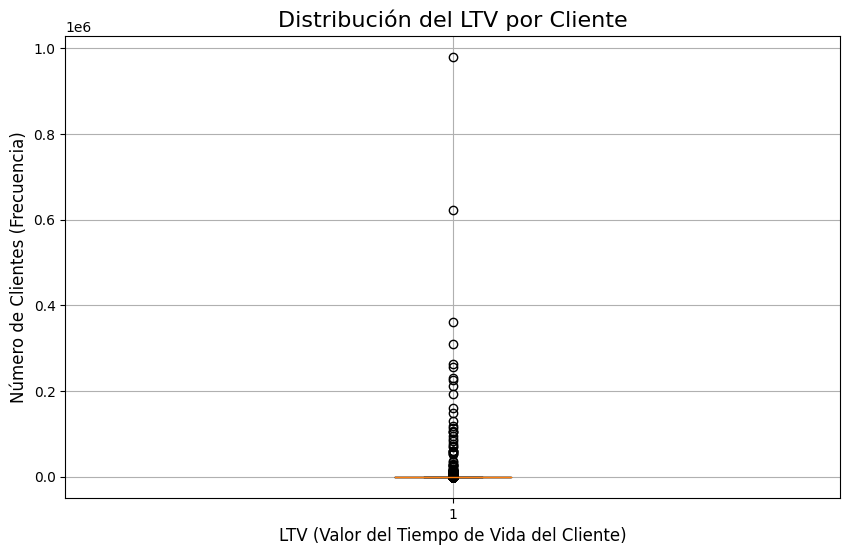

In [80]:
#Vamos a crear un histograma para ver la distribucion de LTV
ltv_data = unir_clientes['LTV'].dropna()
plt.figure(figsize=(10, 6))
plt.boxplot(ltv_data)
# Añadir etiquetas y título
plt.title('Distribución del LTV por Cliente', fontsize=16)
plt.xlabel('LTV (Valor del Tiempo de Vida del Cliente)', fontsize=12)
plt.ylabel('Número de Clientes (Frecuencia)', fontsize=12)
plt.grid(True)
plt.show()

- Vemos que tenemos valores a tipicos en el valor del tiempo de vida del cliente, y la gran mayoria de datos se encuentra concentrado por encima del promedio que es 190

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo hasta este punto! Calculaste muy bien las métricas de negocio y las explicas correctamente con las gráficas y tus comentarios lo cual deja claro el mensaje que se quiere compartir sin importar si la audiencia a la que expongas tus resultados sea técnica o no.
</div>

### 3. Marketing:

#### 1.-  ¿Cuánto dinero se gastó?  (Total/por fuente de adquisición/a lo largo del tiempo) 

In [81]:
# Vamos a sacar el total gastado de la tabla costs_us
total_cost_us = costs_us['costs'].sum() 
total = "{:,}".format(total_cost_us)
print("El total gastado por marketing fue de :",total)

El total gastado por marketing fue de : 329,131.62


- Por fuente de adquisición

In [82]:
#Agrupamos por la columna source_id y sumamos los costos en la columna costs
costo = costs_us.groupby('source_id')['costs'].sum()
print(costo)


source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64


- Vemos que la fuente de anuncio numero 3 es la mas costosa y la numero 9 y 10 las mas baratas

<function matplotlib.pyplot.show(close=None, block=None)>

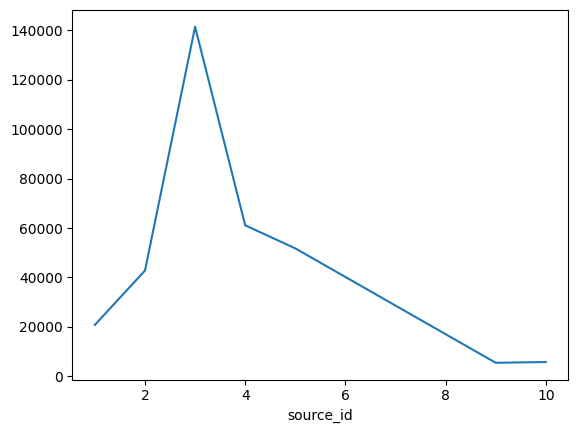

In [83]:
#Vamos a realiazar un grafico de barras para ver estos datos de mejor manera
costo.plot()

plt.show


- A lo largo del tiempo

In [84]:
#Vamos a obtener el mes, año y dia de la columna dt para hacer la cohorte de tiempo
costs_us['month'] = costs_us['dt'].dt.month
costs_us['year'] = costs_us['dt'].dt.year
costs_us['day'] = costs_us['dt'].dt.day

In [85]:
#hacemos un groupby con la columna month y sumamos los costos por mes
costo_mes = costs_us.groupby('month')['costs'].sum()
print(costo_mes.head(12))

month
1     33518.52
2     32723.03
3     30415.27
4     22289.38
5     22224.27
6     18015.00
7     18240.59
8     14790.54
9     24368.91
10    36322.88
11    37907.88
12    38315.35
Name: costs, dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

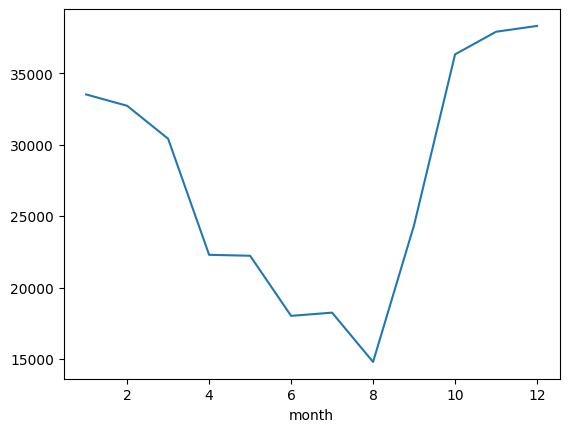

In [86]:
costo_mes.plot()
plt.show

- Notamos un costo mucho menor para el mes de Julio y Agosto, sera que la gente en esos meses tienen muchos gastos esto por las fechas de inicio de clases. Y los meses con mas costo son diciembre, noviembre y octubre el costo para esas fechas sube paulatinamente. 

#### 2.- ¿Cuál fue el costo de adquisición de clientes de cada una de las fuentes?

In [87]:
numerador_cac = costs_us.groupby('source_id')['costs'].sum()

print(numerador_cac.head(10))
numerador_cac = numerador_cac.to_frame()

source_id
1      20833.27
2      42806.04
3     141321.63
4      61073.60
5      51757.10
9       5517.49
10      5822.49
Name: costs, dtype: float64


In [88]:


#Agrupamos por sourced_id y obtenemos los valores unicos de usuarios para obtener los usuario unicos en cada fuente  de anuncio
fuentes_con_costos = costs_us['source_id'].unique()
visits_filtrado = visits_log[visits_log['source_id'].isin(fuentes_con_costos)]


clientes_fuente = visits_filtrado.groupby('source_id').agg({'uid':'nunique'})
print(clientes_fuente.head(10))


             uid
source_id       
1          18999
2          26245
3          74756
4          83525
5          56974
9           9264
10          8067


In [89]:
#CAC = Costo total de marketing por fuente / Número de clientes únicos adquiridos por esa fuente
#Combinamos datos con un merge del costo de las fuentes por el numero de clientes unicos por source_id
cac_data = numerador_cac.merge(clientes_fuente, on='source_id',how='inner')
cac_data['cac'] = cac_data['costs'] / cac_data['uid']
# Primero, agregar costos y clientes por mes
costos_mensuales = costs_us.groupby('month').agg({'costs': 'sum'})
clientes_mensuales = visits_log.groupby('month').agg({'uid': 'nunique'})

# Luego combinar y calcular CAC mensual
cac_mensual = costos_mensuales.merge(clientes_mensuales, on='month', how='inner')
cac_mensual['CAC'] = cac_mensual['costs'] / cac_mensual['uid']
print(cac_data.reset_index())

   source_id      costs    uid       cac
0          1   20833.27  18999  1.096546
1          2   42806.04  26245  1.631017
2          3  141321.63  74756  1.890439
3          4   61073.60  83525  0.731201
4          5   51757.10  56974  0.908434
5          9    5517.49   9264  0.595584
6         10    5822.49   8067  0.721766


- Vemos que la fuente 3 es la mas costosa con mas de 141k y la mas barata es la fuente 9 con un 5.5k. y el costo de adquisicion del cliente de la fuente 9 es la mas barata con .59 dolares a comparacion con la fuente 3 que se paga 1.89 por usuario. Deberiamos replantear el gasto a otra fuente. 

In [90]:
# Primero, agregar costos y clientes por mes
costos_mensuales = costs_us.groupby('month').agg({'costs': 'sum'})
clientes_mensuales = visits_log.groupby('month').agg({'uid': 'nunique'})

# Luego combinar y calcular CAC mensual
cac_mensual = costos_mensuales.merge(clientes_mensuales, on='month', how='inner')
cac_mensual['cac_mes'] = cac_mensual['costs'] / cac_mensual['uid']

print(cac_mensual)
cac_mensual.reset_index(inplace=True)


          costs    uid   cac_mes
month                           
1      33518.52  28707  1.167608
2      32723.03  28755  1.137994
3      30415.27  27475  1.107016
4      22289.38  21004  1.061197
5      22224.27  20698  1.073740
6      18015.00  13267  1.357880
7      18240.59  14183  1.286088
8      14790.54  11631  1.271648
9      24368.91  18968  1.284738
10     36322.88  29692  1.223322
11     37907.88  32798  1.155799
12     38315.35  31560  1.214048


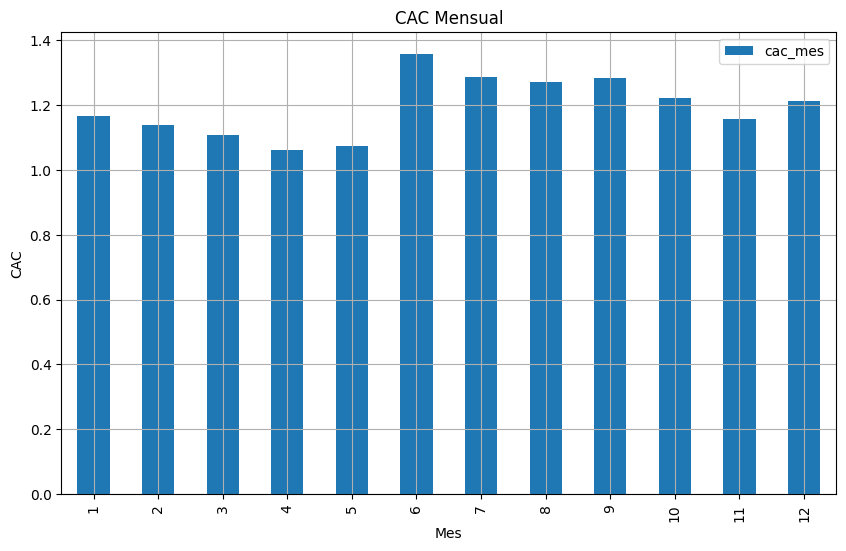

In [91]:
#Hacemos un grafico de barras para ver la tendencia de cac por mes
cac_mensual.plot(x='month', y='cac_mes', kind='bar', figsize=(10, 6))
plt.title('CAC Mensual')
plt.xlabel('Mes')
plt.ylabel('CAC')
plt.grid(True)
plt.show()

- vemos que en los meses a partir de octubre, noviembre diciembre los costos del marketing aumentan considerablemente será porque en esas fechas tienen mas demanda y necesitan pagar mas publicidad para atraer y retener a los usuarios.
- El costo de adquisicion en el mes de abril es el mas barato con 1.06 y el mas caro esta en junio con 1.35 

#### 3.- ¿Cuán rentables eran las inversiones? (ROMI)

In [92]:
#Para calcular el ROMI dividimos el LTV entre el cac
# LTV promedio de todos los clientes
ltv_promedio = unir_clientes['LTV'].mean()

# CAC promedio de todos los meses
cac_promedio = cac_mensual['cac_mes'].mean()

# ROMI general
romi_general = ltv_promedio / cac_promedio
print(romi_general)

159.50706882547897


In [93]:
#Vamos a obtener el romi mensual
# Calculamos el ROMI mensual
romi_mensual = pd.DataFrame({
    'month': cac_mensual['month'],
    'ROMI': (ltv_promedio / cac_mensual['cac_mes'])
})
print(romi_mensual)

    month        ROMI
0       1  163.261388
1       2  167.509858
2       3  172.197378
3       4  179.632342
4       5  177.533939
5       6  140.384440
6       7  148.220997
7       8  149.904108
8       9  148.376782
9      10  155.825915
10     11  164.929512
11     12  157.016289


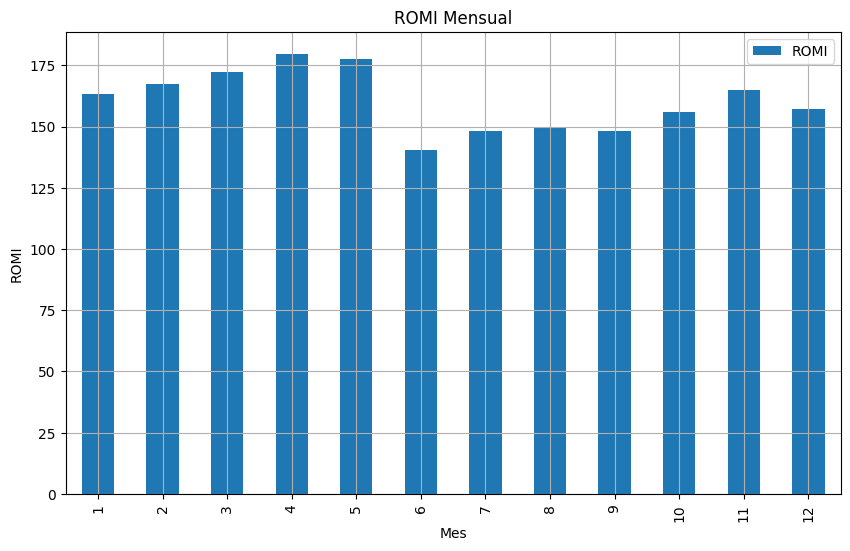

In [94]:
#Hacemos un grafico de barras para ver mejor los valores
romi_mensual.plot(x='month', y='ROMI', kind='bar', figsize=(10, 6))
plt.title('ROMI Mensual')
plt.xlabel('Mes')               
plt.ylabel('ROMI')
plt.grid(True) 

In [95]:
# ROMI por fuente de adquisición
romi_por_fuente = cac_data.copy()
romi_por_fuente['ROMI'] = ltv_promedio / romi_por_fuente['cac']
print(romi_por_fuente) 

               costs    uid       cac        ROMI
source_id                                        
1           20833.27  18999  1.096546  173.841640
2           42806.04  26245  1.631017  116.875110
3          141321.63  74756  1.890439  100.836538
4           61073.60  83525  0.731201  260.701466
5           51757.10  56974  0.908434  209.839521
9            5517.49   9264  0.595584  320.064496
10           5822.49   8067  0.721766  264.109374


## Paso 3. Escribe una conclusión: aconseja a los expertos de marketing cuánto dinero invertir y dónde

### 1.- ¿Qué fuentes/plataformas recomendarías?  Fundamenta tu selección: 

- Las fuentes que recomendaría serian la 9 y 10 ya que son las mas baratas y tienen un costo de adquisicion de clientes muy bajo, ademas de que tienen un buen retorno de inversion.

### 2.- ¿en qué métricas te enfocaste?  ¿Por qué?

- Las metricas que se tomaron en cuanta fueon el costo de adquisicion de clientes, el costo de marketing, romi y el ltv.
El costo de adquisicion de clientes es importante porque nos dice cuanto estamos pagando por cada usuario que adquirimos, el costo de marketing nos dice cuanto estamos invirtiendo en publicidad y el romi nos dice si nuestras inversiones estan siendo rentables. El ltv nos dice cuanto dinero nos esta generando cada cliente a lo largo del tiempo.

### 3.- ¿Qué conclusiones sacaste después de encontrar los valores métricos?

- La conclusion que saque es que debemos enfocarnos en las fuentes de marketing que nos estan generando mas usuarios y que tienen un costo de adquisicion bajo, ademas de que debemos invertir mas en los meses donde hay mas demanda como octubre, noviembre y diciembre. Tambien debemos replantear el gasto en la fuente 3 ya que es la mas costosa y no nos esta generando un buen retorno de inversion.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Tienes un muy buen análisis de este proyecto, te felicito!

Siempre este tipo de análisis que son un poco más complejos hay que buscar cómo explicarlos de manera sencilla considerando la audiencia a la cual se va a presentar los resultados y es ahí donde las visualizaciones juegan un papel muy importante ya que con una visualización es mucho más fácil entender la explicación que con solo valores numéricos.

Muy buen trabajo, saludos!
</div>